# Genuttrykk

I denne øvelsen skal vi bruke data fra genuttrykksmålinger i menneske og mus til å belyse kompetansemål i både biologi 1 og biologi 2. Hovedsaklig vil dette være:

#### Biologi 1:

- gjere greie for oppbygginga av og funksjonen til sentrale organsystem i kroppen
- trekkje ut informasjon frå biologiske tekstar, brosjyrar, aviser, bøker og frå Internett, og vurdere korleis informasjonen er underbygd

#### Biologi 2:

- finne fram til ny kunnskap i biologi frå ulike medium
- gjere greie for transkripsjon og translasjon av gen og forklare korleis regulering av gen kan styre biologiske prosessar

## Celletyper og genregulering

Kroppen vår består av hundrevis av ulike celletyper som utfører spesialiserte oppgaver i kroppen (https://en.wikipedia.org/wiki/List_of_distinct_cell_types_in_the_adult_human_body). Alle celler inneholder det samme DNAet og dermed den samme informasjonen om proteinoppskrifter. Men celler har ulik funksjon (litt forenklet) fordi de ikke produserer de samme proteinene proteiner. Det som avgjør hvilke protein som skal produseres i de ulike celltypene er defineres av reguleringen av transkripsjon i hver celle og vev.

Sekvenseringen av det humane genom i 2000 var en teknologisk bragd, som på mange måter revolusjonerte molekylærbiologien og genetikkfagene. Etter dette har store ressurser har blitt satt inn på å kartlegge hvordan gener blir regulert i ulike utviklingstrinn og i ulike vev/celletyper.

## Datasettet

Ett prosjekt som har som mål om å forstå ‘funksjonen’ og reguleringen til alle gener i vårt genom er Encyclopedia of DNA Elements (ENCODE, https://www.encodeproject.org). Dette prosjektet er et stort internasjonalt samarbeid som samler inn og systematiserer data som gir innsikt i hvordan geners transkripsjon reguleres.

I denne øvelsen har vi hentet inn et datasett fra ENCODE prosjektet, nærmere bestemt målinger av mRNA nivå (genuttrykk), fra ulike vev fra menneske og mus.

Vi skal her blant annet bruke et bibliotek vi ikke har sett på før som heter pandas, som er spesielt godt egnet til å vise denne type data. Dette er ikke nødvendig å sette seg inn i med mindre man er veldig ivrig.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Les inn datafilen "genuttrykk_menneske_data.txt" og gjør deg kjent med hvilke vev og hvor mange gener vi har målt uttrykket til. I filen "genuttrykk_menneske_data.txt" er dataene separert med mellomrom. For at det ikke skal fylles altfor mye opp, så printer vi kun de 5 første kolonnene i filen. Kan godt bytte ut "data_H.head(5)" med "data_H" for å se "hele" datamengden.

In [3]:
data_H = pd.read_csv("genuttrykk_menneske_data.txt", sep=' ')  # Menneskedata
print(data_H.head(5))   # Printer de 5 første radene 

     adipose    adrenal      brain    sigmoid      heart     kidney  \
0  10.917911  11.132391  11.477098  10.898785  10.700243  11.022532   
1  10.313388  10.222082  10.160862   9.510906   9.924935   9.232539   
2   8.917812  10.168201   7.302432   7.108410   8.501513   8.062050   
3  10.691934  11.624016  11.858252   9.964326  11.148979  11.300358   
4   6.998888   6.680445   3.066773   2.511607   6.871629   5.684923   

       liver       lung      ovary   pancreas     spleen  small.bowel  \
0  11.461032  12.012224  11.415880  10.671052  12.104796    11.703182   
1  10.611900   9.624576  10.948366  10.098277  10.436853    10.521029   
2   8.923318   7.935285   9.336374   8.560311   8.623422     9.481058   
3  11.773213  12.218354  10.887794  11.427538  11.116170    11.245304   
4   9.852143   6.627093   7.472242   6.946767   8.632449     1.024817   

      testis    genes  
0   9.955382    STAG2  
1   9.891500    STAG1  
2   8.892800    GOSR2  
3  10.065658  C1orf43  
4   4.762854  

### Oppgave 1

1) **Hva er de forskjellige typene vev på norsk?**

2) **Hent inn for dataene for mus på samme måte. Filen for mus heter "genuttrykk_mus_data.txt"**

3) **Er de samme vevene samlet inn fra begge artene?**

Vi skal nå fokuserer på enkelte av vevstypene, og tar vekk vevene "testies", "ovary", "sigmoid", og "adipose" med følgende kodesnutt.

In [4]:
data_H = data_H.drop(columns=["testis", "ovary", "sigmoid", "adipose"], axis=1)

Vi lager så en liste med navnet på vevene, merk at vi derfor tar vekk kolonnenavnet "genes". Dette kommer vi til å få bruk for litt senere i koden vår.

In [5]:
vev_navn = list(data_H.columns)
vev_navn.remove("genes")

### Tips 
I denne hele oppgaven må vi være detektiver og lese oss opp på funksjoner til ulike gener ved hjelp av ulike databaser på nettet. Vi anbefaler www.genecards.org eller www.proteinatlas.org for å finne detaljert informasjon om gener og deres proteinprodukt. I tillegg har wikipedia også ofte gode sider om disse genene/proteinene.

## Dypdykk

Nå skal vi utforske datasettet vårt ved å grave litt i genuttrykksmønstrene. Vi starter å kun se på data fra mennesket.

To av vevene i vårt datasett er hormonproduserende, binyrer (engelsk: adrenal) og bukspyttkjertelen (engelsk: pancreas). En av de viktigste oppgavene til binyrene er å produsere adrenalin, mens en av bukspyttkjertelens viktigste oppgaver er å produsere insulin og glucagon som regulerer glukoseinnholdet i blodet. Produksjon av adrenalin skjer ved kjemisk modifisering (methylering) av noradrenalin. Denne reaksjonen blir katalysert av ensymet phenylethanolamine N-methyltransferase som kodes for av **PNMT** genet. Glucagon produseres ved å spalte preglucagon, et protein kodet for av genet **GCG**.

Vi starter med å finne hvilken rad PNMT og GCG genet er i tabellen over vevsuttrykk.

Hint: Her må vi først hente ut kun kolonnen med genuttrykk og gjøre om til en liste. En liste har muligheten til å returnere indeksen til et element med .indeks() metoden.

In [6]:
gener = list(data_H["genes"])
rad_GCG = gener.index("GCG")
rad_PNMT = gener.index("PNMT")
print("GCG er i rad", rad_GCG)
print("PNMT er i rad", rad_PNMT)

GCG er i rad 287
PNMT er i rad 9734


Henter så ut verdien for alle vevstypene i de to radene.

Hint: Anbefaler her å droppe kolonnen med gentypen, siden den ikke skal brukes lengere. Kommandoen for å hente ut en rad er `.iloc[]`.

In [7]:
vev_H = data_H.drop('genes', axis=1) 
GCG_vals = vev_H.iloc[rad_GCG]         
PNMT_vals = vev_H.iloc[rad_PNMT]
print("Vevstypene for GCG er gitt ved:\n")
print(GCG_vals)
print()
print("Vevstypene for PNMT er gitt ved:\n")
print(PNMT_vals)

Vevstypene for GCG er gitt ved:

adrenal         0.249365
brain          -0.397812
heart           1.094136
kidney          1.094136
liver           1.094136
lung            0.249365
pancreas       10.927471
spleen          1.094136
small.bowel     5.400613
Name: 287, dtype: float64

Vevstypene for PNMT er gitt ved:

adrenal        7.364429
brain         -0.064505
heart          4.320740
kidney         0.331692
liver          0.331692
lung          -0.505306
pancreas       3.525452
spleen         0.331692
small.bowel    0.331692
Name: 9734, dtype: float64


Lag en figur som viser uttrykket av disse genene over alle vev. 

Hint: Her kommer panda-pakken i bruk. Den gjør at vi kan plotte en "bar"-plot veldig enkelt og elegant, se kode under.

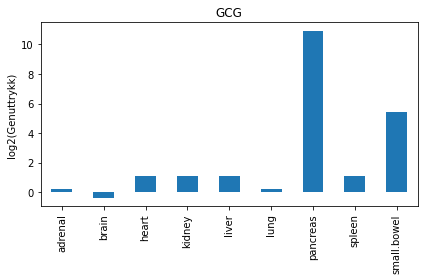

In [8]:
plt.figure()
GCG_vals.plot(kind='bar', title="GCG")    # Lager et barplott (histogram) med tittel GCG
plt.ylabel("log2(Genuttrykk)")            # Navn på y-aksen
plt.tight_layout()                        # Dette gjøre at plottet ser ryddigere ut

### Oppgave 2

1) **Lag et tilsvarende plot for PNMT.**

2) **Virker resultatene logiske utifra det dere kan om produksjonen av disse hormonene?**

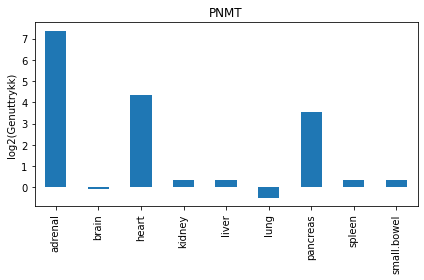

In [9]:
plt.figure()
PNMT_vals.plot(kind='bar', title="PNMT")
plt.ylabel("log2(Genuttrykk)")
plt.tight_layout()

## Mønster

La oss nå se nærmere på noen hovedmønstre i datasettet vårt. Start med å lage en kode som først trekker ut de 100 høyest uttrykte genene for hvert vev. Dette er ganske kompekst så dette bør man hoppe over med elever.

**For læreren:**

Starter med å sortere genuttrykk basert på en vevstype. Deretter tar vi ut de 100 med størst frekvens for alle vevstypene.

In [10]:
def hent_høye_genuttrykk(df, navn): 
    sortert_df = df.sort_values(navn) # Henter ut kun kolonnen med genuttrykk or sort ordner dem etter størrelse
    genuttrykk_sortert = sortert_df["genes"]
    gener_høyt = list(genuttrykk_sortert[-100:]) # De bakerste 100 elementene tilsvarer de største verdiene
    return gener_høyt

alle_høye_lister = []
for navn in vev_navn:   # Løper gjennom alle gentypene og sjekker om de er tilstede
    alle_høye_lister.append(hent_høye_genuttrykk(data_H, navn))
print("Antall lister: ", len(alle_høye_lister))
print("Lengde første liste: ", len(alle_høye_lister[0]))


Antall lister:  9
Lengde første liste:  100


Søker deretter gjennom de 100 med størst frekvens i alle genuttrykene. Hvis et getuttrykk *ikke* finnes i en annen topp 100 blir det tatt vekk fra listen. Vi står da igjen med genuttrykkene som er representert i alle de topp 100 for alle vevstypene.

In [11]:
hovedliste = alle_høye_lister[0]
potensielle_høye = hovedliste.copy()   # Lager en kopi av listen slik at elementer kan slettes underveis
for i in range(100):
    pot_gen = hovedliste[i]
    for vev in alle_høye_lister[1:]: # Løkker over listene fra og med den andre listen
        if pot_gen not in vev:
            potensielle_høye.remove(pot_gen)
            break    # Bryter ut av løkken hvis vi fjerner et element
print("Antall høyt uttrykte gen: ", len(potensielle_høye))
print("Navn på høyt uttrykte gen: ", potensielle_høye)

Antall høyt uttrykte gen:  6
Navn på høyt uttrykte gen:  ['DDX5', 'B2M', 'TPT1', 'EIF4G2', 'ACTB', 'GNAS']


Gjør tilsvarende for lavt uttrykte gen.

In [12]:
def hent_lave_genuttrykk(df, navn):
    sortert_df = df.sort_values(navn)
    genuttrykk_sortert = sortert_df["genes"]
    gener_lavt = list(genuttrykk_sortert[:100])
    return gener_lavt


alle_lave_lister = []
for navn in vev_navn:
    alle_lave_lister.append(hent_lave_genuttrykk(data_H, navn))

hovedliste = alle_lave_lister[0]
potensielle_lave = hovedliste.copy()   # Kopierer listen over de 100 potensielle uttrykkene for å kunne slette elementer underveis
for i in range(100):
    pot_gen = hovedliste[i]
    for vev in alle_lave_lister[1:]: # Løkker over listene fra og med den andre listen
        if pot_gen not in vev:
            potensielle_lave.remove(pot_gen)
            break    # Bryter ut av løkken hvis vi fjerner et element
print("Antall lavt uttrykte gen: ", len(potensielle_lave))
print("Navn på høyt uttrykte gen: ", potensielle_lave)

Antall lavt uttrykte gen:  0
Navn på høyt uttrykte gen:  []


### Oppgave 3

**Bruk internet for å finne funksjonen til de 6 genene som er høyt uttrykt i alle vev. Diskuter hva slags funksjoner som er felles for disse genene.**

### Oppgave 4

**Legg vekk PCen og diskuter:**

1) **Hva slags cellefunksjoner forventer vi at styres av gener som ikke varierer mye i genuttrykk mellom ulike celler?**

2) **Er genene som uttrykkes i alle celler vanligvis lavt eller høyt uttrykt?**

Da skal vi bruke koding til å sjekke om dere har tenkt i riktige baner. For å finne gener som varierer mye/lite mellom vev (også referert til som vevsspesifisitet) skal vi nå lage en kode som leter systematisk etter slike gener. Hvis vi tenker algoritmisk på dette problemet trenger vi å gjøre følgende:

- For hvert gen (rad i vår tabell) regn ut et mål på variasjon i genuttrykket (verdiene) mellom vev, dvs kolonner i tabellen
- Lagre dette variasjonsmålet for hver rad
- Bruke verdien for hvor mye variasjon det er i genuttrykkene til å trekke ut de mest/minst varierende genene og visualiser/studer resultatene.

In [13]:
variasjonskoeffisienter = []
gjennomsnitt_vev = []
std_vev = []
antall_rader = len(gener)       # Lengden på listen over gener er lik antall rader vi har
for i in range(antall_rader):   # Løper gjennom alle radene
    m = np.mean(vev_H.iloc[i])  # Bruker innebygde metoder for gjennomsnitt og standardavvik.
    stdev = np.std(vev_H.iloc[i])
    var_koeff = stdev / m * 100
    gjennomsnitt_vev.append(m)
    std_vev.append(stdev)
    variasjonskoeffisienter.append(var_koeff)

Her får vi noe litt rart utifra dataene våre. To av verdiene blir under null. Disse fjerner vi, men hvorfor skjer de i utgangspunktet?

In [14]:
print('Antall verdier under 0 (før): ', np.sum(np.array(variasjonskoeffisienter) < 0))

for i in range(antall_rader):
    if variasjonskoeffisienter[i] < 0:
        variasjonskoeffisienter[i] = 0

Antall verdier under 0 (før):  2


Tilslutt plotter vi et histogram over variasjonskoeffisient til genuttrykket

Text(0, 0.5, 'Antall')

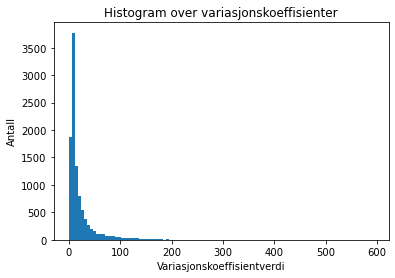

In [15]:
plt.figure()
plt.hist(variasjonskoeffisienter, bins=100)
plt.title("Histogram over variasjonskoeffisienter")
plt.xlabel("Variasjonskoeffisientverdi")
plt.ylabel("Antall")

### Oppgave 5

**Er det vanligst at gener har stor variasjon i genuttrykk mellom vev?**

I **oppgave 3** og i **oppgave 4** fant vi ut at høyt uttrykte gener ofte er høyt uttrykte i flere vev. Dersom dette er en generell trend foventer vi å se en sammenheng mellom geners ‘vevsspesifisitet’ (som vi har målt som variasjonskoeffisient) og geners uttrykksnivå. Vi plotter variasjonskoeffisienten mot gjenomsnittet (som vi regnet ut for hvert vev over).

Text(0, 0.5, 'Variasjonskoeffisient')

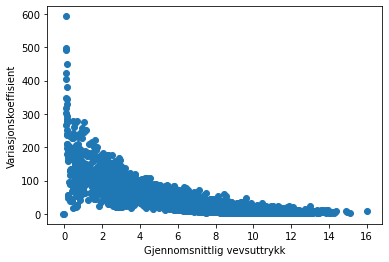

In [16]:
plt.figure()
plt.scatter(gjennomsnitt_vev, variasjonskoeffisienter)
plt.xlabel("Gjennomsnittlig vevsuttrykk")
plt.ylabel("Variasjonskoeffisient")

Vi skal se på to eksempler på gener som er høyt uttrykt. Beta-aktin (**ACTB**) (se liste over høyt uttrykte gener) og gener som koder for ribosomale proteiner.

La oss legge på informasjon om hvor slike typiske ‘housekeeping genes’ befinner seg i plottet over. Finner først radene som har gener som koder for ribosomale subinuts (disse begynner på ‘**RPS**’) og deretter beta-aktin (**ACTB**).

In [17]:
rps_rader = []
actb_rader = []
for i in range(antall_rader):
    if gener[i].startswith("RPS"):
        rps_rader.append(i)
    elif gener[i].startswith("ACTB"):
        actb_rader.append(i)

x = np.array(gjennomsnitt_vev)
y = np.array(variasjonskoeffisienter)
rps_arr = np.array(rps_rader)
actb_arr = np.array(actb_rader)

Vi kan nå legge på et nytt lag av informasjon på plottet over der vi uthever disse genene spesifikt

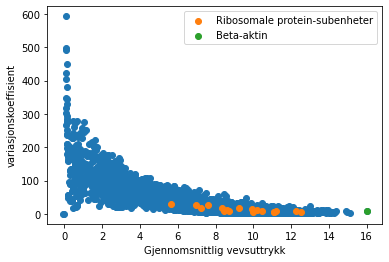

In [18]:
plt.figure()
plt.scatter(x, y)
plt.scatter(x[rps_arr], y[rps_arr], label='Ribosomale protein-subenheter')
plt.scatter(x[actb_arr], y[actb_arr], label='Beta-aktin')
plt.xlabel("Gjennomsnittlig vevsuttrykk")
plt.ylabel("variasjonskoeffisient")
plt.legend()

### Oppgave 6

**Diskuter hva denne grafen viser og hvorfor det er rimelig at det må være slik**

Så langt har vi sett at gener som er høyt uttrykt også oftest varierer lite i genuttrykk mellom vev. Slike gener blir referert til som ‘housekeeping genes’ - og disse er som navnet tilsier involvert i helt basale prosesser i cellen som alle celler må utføre for å overleve.

## Sammenligne mus og mennesker

Her skal vi bruke hele det originale datasettet, med genuttrykk fra både mus og menneske, for å belyse viktige prinsipp innen evolusjon.

### Oppgave 7

**Diskuter ut ifra det dere kan om evolusjonsbiologi, om vi vil forvente at genuttrykksmønstrene fra samme vev i menneske og mus er likere hverandre enn de er andre vev i samme art?**

Vi starter med å hente inn filen med data fra mus. Mye av denne koden er lik den vi hadde for mennesker i starten av dokumentet.

In [19]:
data_M = pd.read_csv("genuttrykk_mus_data.txt", sep=' ') 

data_M = data_M.drop(columns=["testis", "ovary", "sigmoid", "adipose"], axis=1)
vev_M = data_M.drop('genes', axis=1) 

Korrelerer deretter dette med filen for mennesker. Dersom de samme genene er høyt/lavt uttrykt i samme vev i mus og menneske, så vil korrelasjonen være høy.

In [20]:
korrelasjon = vev_H.corrwith(vev_M) 
print("Korrelasjon mellom genuttrykk i menneske og mus\n")
print(korrelasjon)

Korrelasjon mellom genuttrykk i menneske og mus

adrenal        0.831616
brain          0.785173
heart          0.900425
kidney         0.870699
liver          0.886387
lung           0.819862
pancreas       0.783298
spleen         0.838966
small.bowel    0.826635
dtype: float64


Visualiserer tabellen over.

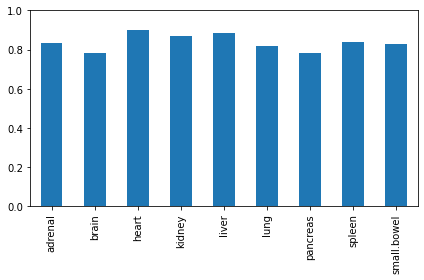

In [21]:
korrelasjon.plot(kind="bar")
plt.ylim([0, 1])
plt.tight_layout()

### Oppgave 8

1) **Studer likheten mellom vevene i mus og menneske. Hva er grunnen til likheten? Hvorfor er noe vev likere enn annet vev?**

2) **Hvordan kan dere forklare dette ut ifra evolusjonsprinsipper?**